# DeepSeek V4 Hybrid Attention：把 KV 压缩到极致（CSA + HCA）

DeepSeek V4（2026-04）的长上下文注意力，是第 08 章 **NSA** 的进化。核心思路没变——**先把相邻 KV 压成
压缩块，再在压缩后的短序列上做注意力**——但把"压缩"和"选块"都做得更激进：

| | 压缩比 | 选块 | 角色 |
|---|---|---|---|
| **CSA**（Compressed Sparse Attention） | 4× | lightning indexer 选 top-k=1024 | 稀疏，保细节 |
| **HCA**（Heavily Compressed Attention） | 128× | 不选（稠密） | 极致省 KV |

V4-Pro 61 层 ≈ 30 CSA + 31 HCA 交替。1M token 上下文下，单 token 推理 FLOP 仅 V3.2 的 **27%**、KV cache 仅 **10%**。

> 本章按约定**自写简要版讲机制**（纯 PyTorch，聚焦 compress→index→attend 主干），**不提取**生产 kernel——
> DSv4 不在 fla，FP4/FP8 量化、dual-stream 重叠压缩、KV cache 工程等在 vLLM/官方实现，见 `SOURCES.md`。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CH = ROOT / "14-deepseek-v4"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(CH))

from common.nbtools import setup_cjk, show_code
setup_cjk()
from deepseek_v4 import softmax_compress, lightning_indexer, compressed_attention, csa_attention, hca_attention

torch.manual_seed(0)
dev = "cuda" if torch.cuda.is_available() else "cpu"
print("跑在", torch.cuda.get_device_name(0) if dev == "cuda" else "CPU")

跑在 NVIDIA GeForce RTX 4090


## 1. 步骤一：学习式 softmax 压缩

每 $m$ 个 token 压成 1 个压缩块。和 NSA 的均值/卷积池化不同，DSv4 用 **per-coordinate softmax 池化**：
每个特征维度**独立**地在 $m$ 个位置上做 softmax 加权——

$$C_i=\sum_{j\in\text{block }i}\text{softmax}_j(Z_{\cdot,d})\odot x_j.$$

权重 $Z$ 由学习投影给出，所以池化方式是**学到的**：$Z$ 平 → 趋近均值；$Z$ 尖 → 趋近"取某个位置"。
下面把同一段序列分别用「均值池化」和「带 $Z$ 的 softmax 池化」压缩，看压缩块如何随 $Z$ 变化。

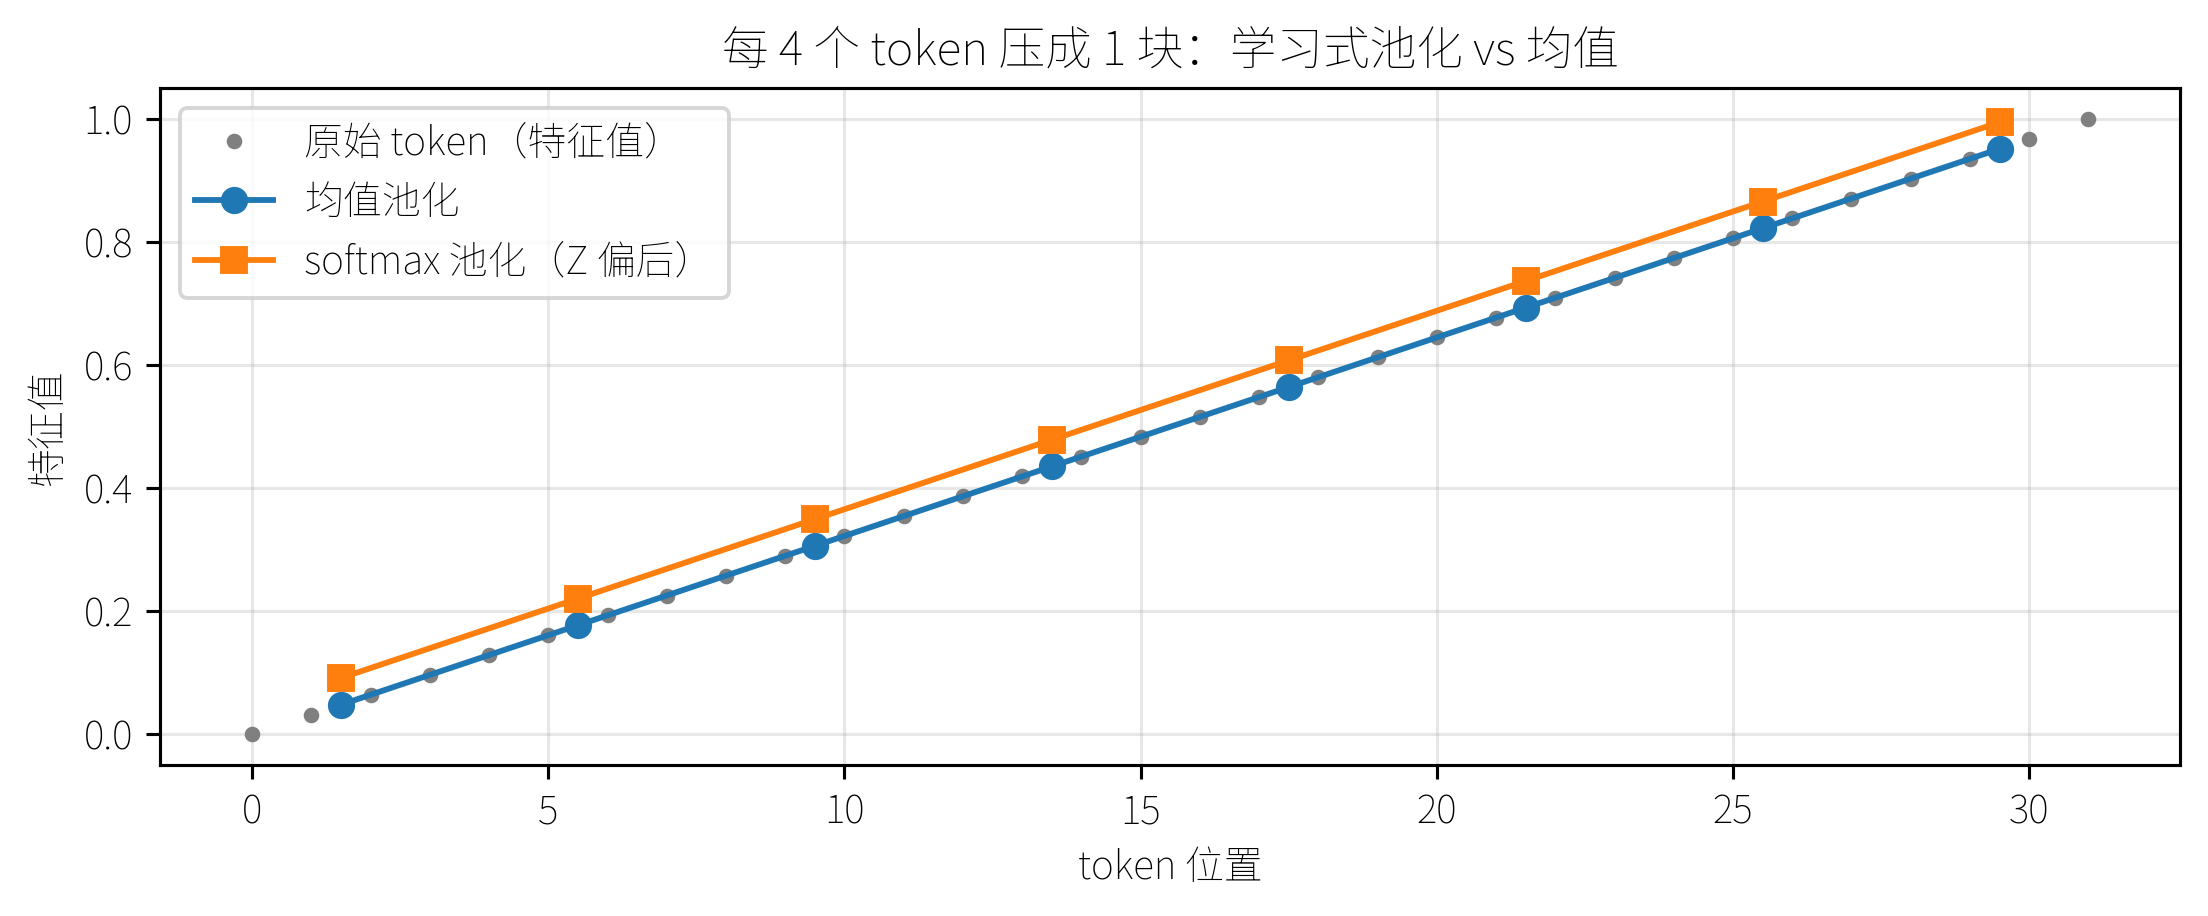

序列 32 → 压缩块 8（缩 4 倍）。softmax 池化的 Z 偏向块内靠后位置，故压缩值高于均值。
压缩后的 C 同时充当 K 和 V —— 每块只缓存一个向量，这是省 KV cache 的关键。


In [2]:
T, m = 32, 4
x = torch.linspace(0, 1, T, device=dev).reshape(1, 1, T, 1).repeat(1, 1, 1, 8)   # 单调上升的特征
nb = T // m

c_mean = softmax_compress(x, m, z=None)                       # 均值池化
z = torch.zeros(1, 1, T, 8, device=dev)
z[..., :] = torch.linspace(-3, 3, m, device=dev).repeat(nb)[None, None, :, None]  # 块内偏向后面的位置
c_soft = softmax_compress(x, m, z=z)

plt.figure(figsize=(8, 3.4))
plt.plot(torch.arange(T).cpu(), x[0, 0, :, 0].cpu(), ".", color="gray", label="原始 token（特征值）")
plt.plot((torch.arange(nb) * m + (m - 1) / 2).cpu(), c_mean[0, 0, :, 0].cpu(), "o-", label="均值池化")
plt.plot((torch.arange(nb) * m + (m - 1) / 2).cpu(), c_soft[0, 0, :, 0].cpu(), "s-", label="softmax 池化（Z 偏后）")
plt.xlabel("token 位置"); plt.ylabel("特征值"); plt.title(f"每 {m} 个 token 压成 1 块：学习式池化 vs 均值")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"序列 {T} → 压缩块 {nb}（缩 {m} 倍）。softmax 池化的 Z 偏向块内靠后位置，故压缩值高于均值。")
print("压缩后的 C 同时充当 K 和 V —— 每块只缓存一个向量，这是省 KV cache 的关键。")

## 2. 步骤二：Lightning indexer 选块（仅 CSA）

给每个 query 选 top-$k$ 个最相关的压缩块：

$$I_{t,s}=\sum_h w_{t,h}\,\text{ReLU}\!\bigl(q^I_{t,h}\cdot K^{IComp}_s\bigr),\quad\text{选 top-}k\text{ 个 }s.$$

是 **ReLU 不是 softmax**——排序信号、非概率（生产实现用 FP4 精度，极省）。块级 causal：query $t$ 只能选
完全落在它之前的块。下面画出每个 query 选中的压缩块（稀疏模式），并和"全用"的稠密模式对比。

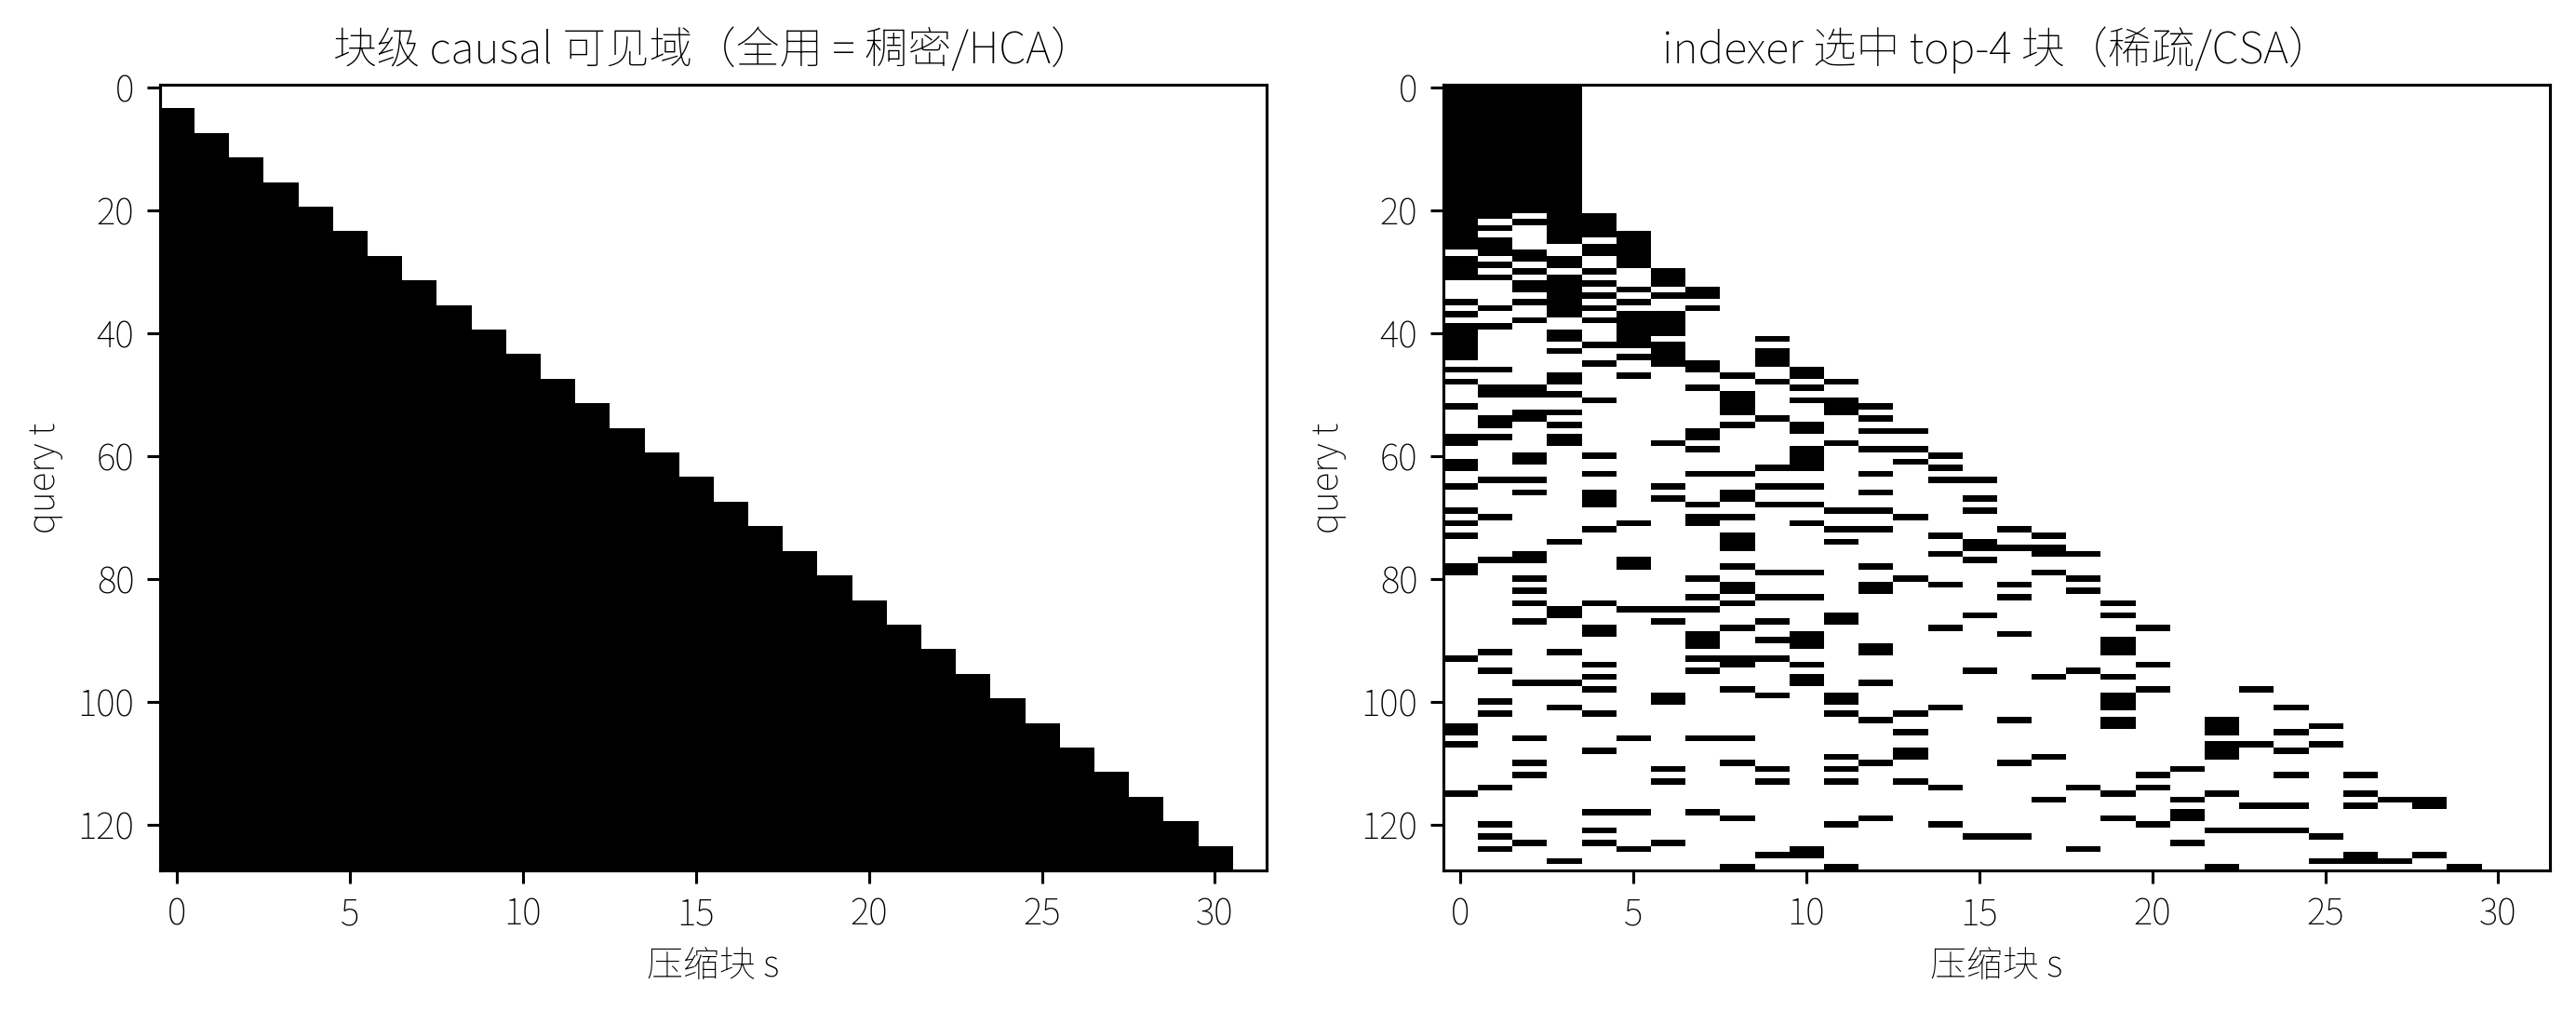

左：每个 query 可见 t//4 个历史块（HCA 全用）。右：CSA 只在其中选 top-4 个算注意力——更稀疏。


In [3]:
B, Hi, T, di = 1, 2, 128, 16
m = 4; nb = T // m; top_k = 4
q_idx = torch.randn(B, Hi, T, di, device=dev)
w_idx = torch.rand(B, Hi, T, device=dev)
k_idx = torch.randn(B, Hi, nb, di, device=dev)
sel, causal = lightning_indexer(q_idx, w_idx, k_idx, top_k=top_k)

# 选中模式 (T, nb)
mask = torch.zeros(T, nb, device=dev)
mask.scatter_(1, sel[0], 1.0)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(causal.cpu(), cmap="Greys", aspect="auto"); ax[0].set_title("块级 causal 可见域（全用 = 稠密/HCA）")
ax[1].imshow(mask.cpu(), cmap="Greys", aspect="auto"); ax[1].set_title(f"indexer 选中 top-{top_k} 块（稀疏/CSA）")
for a in ax:
    a.set_xlabel("压缩块 s"); a.set_ylabel("query t")
plt.tight_layout(); plt.show()
print(f"左：每个 query 可见 t//{m} 个历史块（HCA 全用）。右：CSA 只在其中选 top-{top_k} 个算注意力——更稀疏。")

## 3. 步骤三：压缩块上的注意力 —— CSA / HCA 是同一函数的两种配置

`compressed_attention(q,k,v,m,top_k=...)` 把三步合起来：压缩 → （CSA 才选块）→ 在压缩块上 MQA。
- **CSA** = `compressed_attention(m=4, top_k=1024)`，稀疏；
- **HCA** = `compressed_attention(m=128, top_k=None)`，稠密。

下面验证一个关键退化：当 CSA 的 `top_k` 取满（≥ 可见块数）时，"选块"变成"全选"，CSA **精确退化为** HCA 稠密。

In [4]:
B, Hq, T, D = 2, 4, 128, 32
q = torch.randn(B, Hq, T, D, device=dev)
k = torch.randn(B, 1, T, D, device=dev)            # 共享 KV（MQA）
v = torch.randn(B, 1, T, D, device=dev)
m = 4; nb = T // m
Hi, di = 2, 16
q_idx = torch.randn(B, Hi, T, di, device=dev); w_idx = torch.rand(B, Hi, T, device=dev)
k_idx = torch.randn(B, Hi, nb, di, device=dev)

o_csa = csa_attention(q, k, v, m=m, top_k=4, q_idx=q_idx, w_idx=w_idx, k_idx=k_idx)
o_csa_full = csa_attention(q, k, v, m=m, top_k=nb, q_idx=q_idx, w_idx=w_idx, k_idx=k_idx)
o_hca = hca_attention(q, k, v, m=m)
print("CSA(稀疏 top_k=4) 输出形状:", tuple(o_csa.shape))
print("CSA(top_k=全部) vs HCA(稠密) max diff:", (o_csa_full - o_hca).abs().max().item())
print("→ top_k 取满时选块变全选，CSA 精确退化为 HCA。CSA/HCA 本是同一个 CompAttn 的两种配置。")

CSA(稀疏 top_k=4) 输出形状: (2, 4, 128, 32)
CSA(top_k=全部) vs HCA(稠密) max diff: 0.0
→ top_k 取满时选块变全选，CSA 精确退化为 HCA。CSA/HCA 本是同一个 CompAttn 的两种配置。


## 4. 为什么省：KV cache 与 FLOP

压缩把 $n$ 个 token 的 KV 变成 $n/m$ 个压缩向量（每块 K=V 共用一个）。CSA 再用 indexer 把注意力限制在
top-$k$ 个块上，core 注意力的 FLOP 与序列长度**无关**（只和 $k$ 有关）。HCA 压缩比 128×，KV 几乎可忽略。
下面按 V4-Pro 的量级（压缩维 $c{=}512$、$m{=}4$、$m'{=}128$）画出每 token 的 KV cache 占用对比。

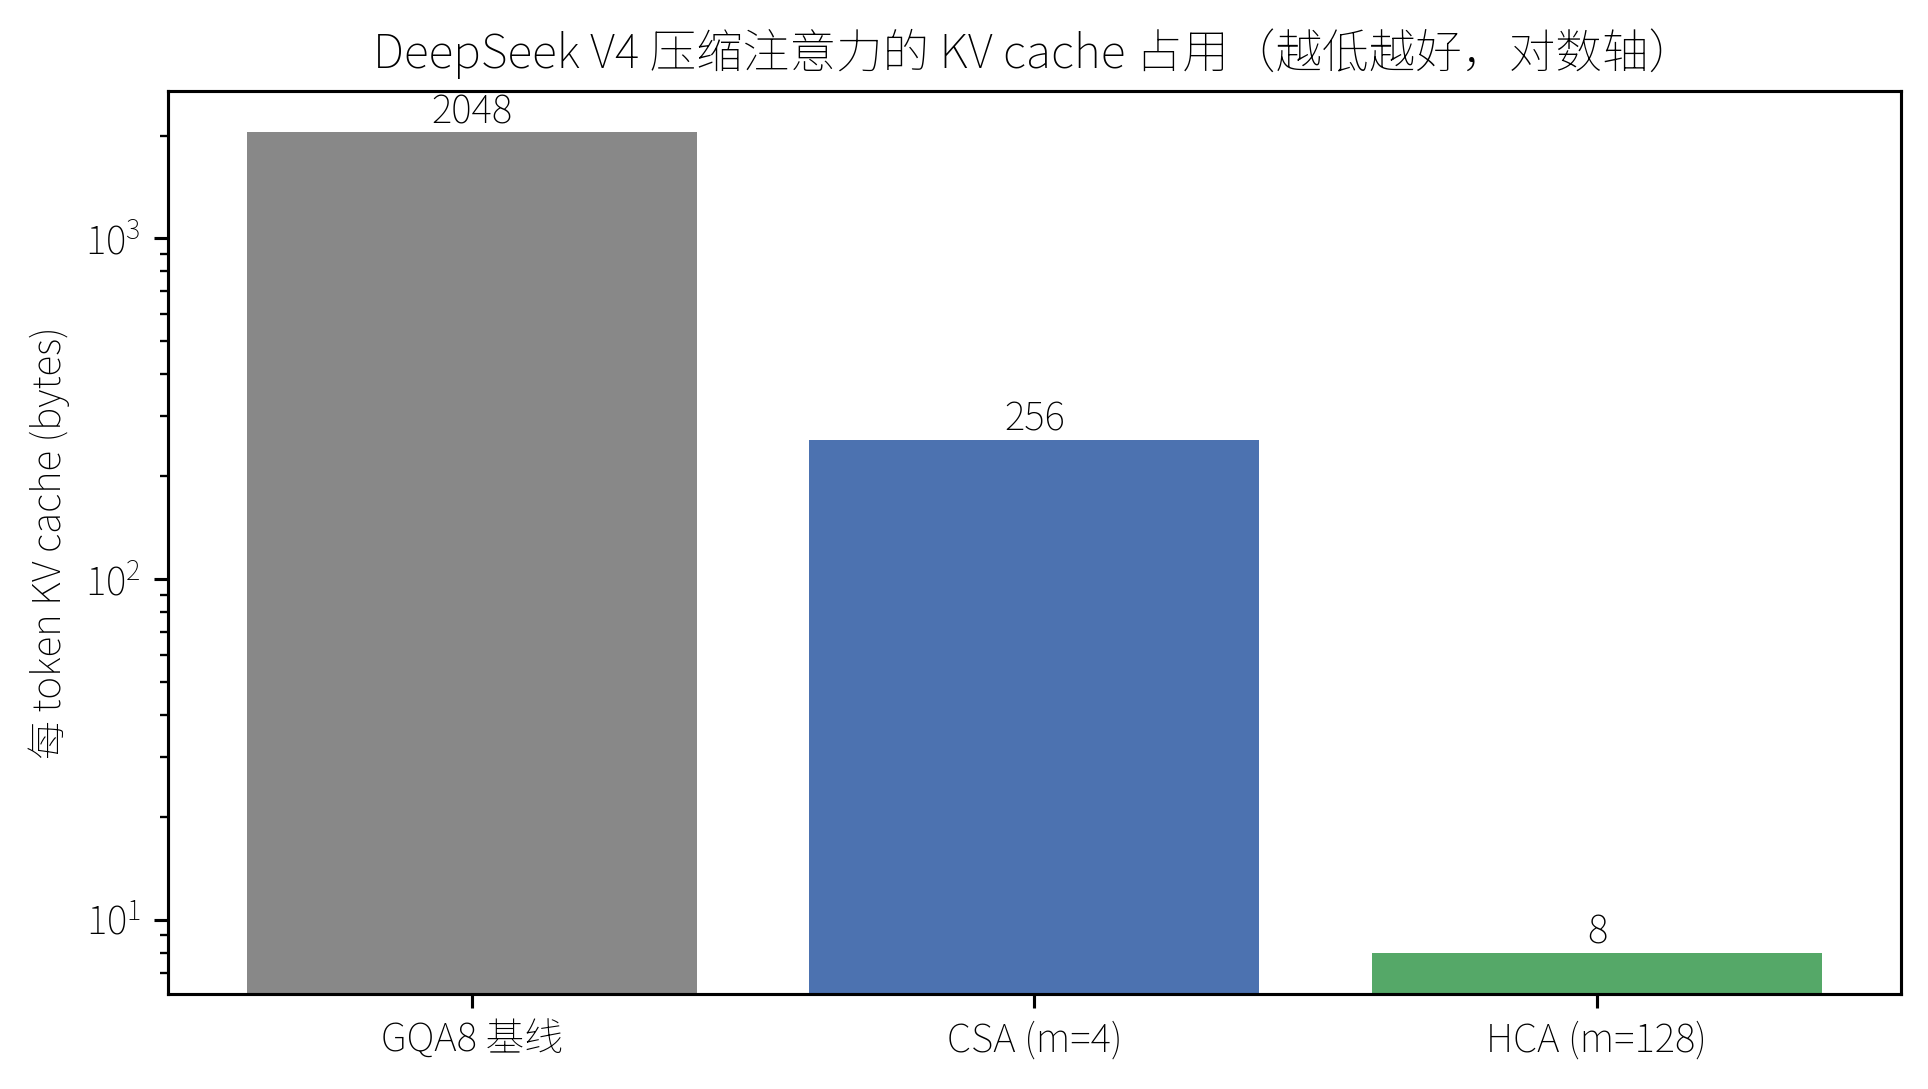

CSA ≈ 基线 12.5%，HCA ≈ 0.4%。两者交替 → 整体 KV cache ≈ 基线 10%（含 FP8 等）。
FLOP：CSA core 只在 top-k=1024 块上算，与序列长度无关；1M 上下文下整体 FLOP 仅 V3.2 的 27%。


In [5]:
# 每 token KV cache 字节（示意，按报告量级）：GQA8 基线 vs CSA vs HCA
labels = ["GQA8 基线", "CSA (m=4)", "HCA (m=128)"]
bytes_per_tok = [2048, 256, 8]            # 来源：技术报告量级（CSA≈12.5%，HCA≈0.4%）
colors = ["#888", "#4C72B0", "#55A868"]
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, bytes_per_tok, color=colors)
plt.ylabel("每 token KV cache (bytes)"); plt.yscale("log")
plt.title("DeepSeek V4 压缩注意力的 KV cache 占用（越低越好，对数轴）")
for b, val in zip(bars, bytes_per_tok):
    plt.text(b.get_x() + b.get_width() / 2, val, f"{val}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print("CSA ≈ 基线 12.5%，HCA ≈ 0.4%。两者交替 → 整体 KV cache ≈ 基线 10%（含 FP8 等）。")
print("FLOP：CSA core 只在 top-k=1024 块上算，与序列长度无关；1M 上下文下整体 FLOP 仅 V3.2 的 27%。")

## 5. 与第 08 章 NSA 的关系

```
NSA（第 08 章）   =  压缩分支  +  选块分支  +  sliding window（局部）
DSv4 CSA          =  压缩分支  +  选块分支     （压缩→softmax 池化，选块→ReLU lightning indexer）
DSv4 HCA          =  压缩到 128×，稠密，不选块
                     （DSv4 没有 sliding window 分支，省全靠压缩 + 稀疏索引）
```

NSA 用三分支覆盖"全局粗看 + 重点细看 + 邻近精看"；DSv4 把它简化成"压缩 + 按需选块"，并把两者都做得更激进。

## 6. 逐段精读：自写简要版 `deepseek_v4.py`

本章是自写机制版（不提取生产 kernel）。下面把 `deepseek_v4.py` 的三个核心函数拆开，每段对应前面 §1–§3 的一条公式。

### 6.1 `softmax_compress` —— 学习式压缩（对应 §1）

```python
def softmax_compress(x, m, z=None):
    B, H, T, D = x.shape
    nb = T // m
    xb = x[:, :, :nb * m].reshape(B, H, nb, m, D)        # 每 m 个 token 一组
    if z is None:
        w = x.new_full((B, H, nb, m, D), 1.0 / m)        # z=None → 均匀权重 = 均值池化
    else:
        zb = z[:, :, :nb * m].reshape(B, H, nb, m, D)
        w = torch.softmax(zb, dim=3)                     # 沿 m 个位置、逐坐标独立 softmax
    return (w * xb).sum(dim=3)                            # 加权求和 → (B,H,nb,D)
```

对应 §1 的 $C_i=\sum_{j}\text{softmax}_j(Z_{\cdot,d})\odot x_j$：`dim=3` 正是在每组 $m$ 个位置上做 softmax，**每个特征
维度 $D$ 独立**（学习式池化）。$z$ 由学习投影给出，所以池化方式是学到的；$z=$`None` 退化为均值池化。压缩后 $C$ 同时
当 K 和 V。

### 6.2 `lightning_indexer` —— ReLU 打分选块（对应 §2）

```python
raw = torch.einsum("bhtd,bhsd->bhts", q_idx, k_comp).relu()   # ReLU(q · k_comp)，排序信号非概率
score = (w_idx.unsqueeze(-1) * raw).sum(dim=1)                # Σ_h w_h · ReLU(...)  → (B,T,nb)
causal = (s_idx * m + m - 1) < t_idx[:, None]                 # 块级 causal：块 s 完全在 t 之前
score = score.masked_fill(~causal[None], float("-inf"))
sel = score.topk(k, dim=-1).indices                          # 选 top-k 个压缩块
```

对应 §2 的 $I_{t,s}=\sum_h w_{t,h}\,\text{ReLU}(q^I_{t,h}\cdot K^{IComp}_s)$。关键是 **ReLU 而非 softmax**——这是排序
信号、不是概率分布（生产实现 FP4 精度算）。`topk` 选出每个 query 最相关的 $k$ 个块；块级 causal 保证只选已完成的历史块。

### 6.3 `compressed_attention` —— 统一 CompAttn（对应 §3）

```python
k_comp = softmax_compress(k, m, z)                            # ① 压缩：C 同时当 K 和 V
v_comp = softmax_compress(v, m, z)
attn = torch.einsum("bhtd,bhsd->bhts", q, k_comp) * scale     # ② query 对压缩块打分
attn = attn.masked_fill(~causal[None, None], float("-inf"))   #    块级 causal
if top_k is not None:                                         # ③ CSA 才选块（HCA top_k=None 跳过）
    sel, _ = lightning_indexer(q_idx, w_idx, k_idx, top_k)
    keep = torch.zeros(B, T, nb, dtype=torch.bool, ...).scatter_(2, sel, True)
    attn = attn.masked_fill(~keep[:, None], float("-inf"))    #    只在选中块上算
p = torch.softmax(attn, dim=-1)
out = torch.einsum("bhts,bhsd->bhtd", p, v_comp)             # ④ 压缩块上的 MQA
```

把三步合起来：压缩 → （CSA 才）indexer 选块 → 压缩块上 softmax 注意力。**CSA** = `top_k=1024` 稀疏、**HCA** =
`top_k=None` 稠密——同一函数两种配置。注意 `top_k` 给定时 indexer 选中的块若含 causal 不可见块，会被 ② 的 causal
mask 再次屏蔽（§4 验证过的退化关系即源于此）。

### 6.4 完整源码（供查阅全貌）

前面拆开的三个函数，连同块级 causal 的边界处理（无历史压缩块的靠前 query 输出置 0）都在下面这一个文件里（可滚动）：

In [6]:
show_code(str(CH / "deepseek_v4.py"))

## 7. 收尾

DeepSeek V4 Hybrid Attention 的三步：

1. **学习式 softmax 压缩**：每 $m$ 个 token 压成 1 块，压缩向量同时当 K 和 V（省 KV cache）；
2. **Lightning indexer**：ReLU 打分 + top-$k$ 选块（CSA 才有），FP4 精度极省；
3. **压缩块上的 MQA**：CSA 稀疏（$m{=}4,k{=}1024$）、HCA 稠密（$m{=}128$），层间交替。

它是第 08 章 NSA"压缩稀疏"思路的最新、最激进形态：1M 上下文下 FLOP/KV 砍到 V3.2 的 27%/10%。

> 本章是**机制简化版**——生产实现的 FP4/FP8 量化、dual-stream 重叠压缩、KV cache 工程见 `SOURCES.md`
> 指向的 vLLM / DeepSeek 官方。至此本仓库覆盖：标准/高效 → GQA/窗口/分页 → MLA → 稀疏（块稀疏/NSA/DSv4）
> → 线性（GLA/DeltaNet/KDA/GDN）两条主线。